## loading necessary libs

In [1]:
# !pip install "alphatims[plotting]"
# !pip install hvplot
# !pip install jupyter_bokeh
# !pip install dask[dataframe]
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
import alphatims.utils
import alphatims.bruker
import alphatims.plotting
import importlib
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import seaborn as sns



### Loading Data

In [3]:


alphatims.utils.set_threads(4)
log_file_name = alphatims.utils.set_logger(
    log_file_name="tutorial_log.txt",
    overwrite=True
)

def reload():
    importlib.reload(alphatims.utils)
    importlib.reload(alphatims.bruker)
    importlib.reload(alphatims.plotting)
    alphatims.utils.set_threads(4)
    alphatims.utils.set_logger(log_file_name="tutorial_log.txt")
    
isDia = True

if (isDia):
    bruker_d_folder_name = "../MS_Data/test1.hdf"
    
else :
    bruker_d_folder_name = ""

data = alphatims.bruker.TimsTOF(bruker_d_folder_name)

2025-04-02 11:40:33> Importing data from ../MS_Data/test1.hdf
2025-04-02 11:40:33> Using HDF import for ../MS_Data/test1.hdf
2025-04-02 11:40:36> Successfully imported data from ../MS_Data/test1.hdf


In [4]:
selected_indices = data[:,:,0, :,"raw"]

In [5]:
# intensities =data.bin_intensities(selected_indices,("rt_values","mz_values"))
# intensities

## Plotting

In [6]:
def plot_lineplot(x_dim,y_dim,selected_indices):
        if data is not None:  # Ensure dataset is loaded
            # Validate selected dimensions
            valid_x_dims = ['mz', 'rt', 'mobility']
            valid_y_dims = ['intensity', 'mz', 'rt', 'mobility']
            if x_dim in valid_x_dims and y_dim in valid_y_dims: 
                # Create the plot
                plot = alphatims.plotting.line_plot(
                    data,
                    selected_indices,
                    x_dim,
                    data.sample_name,
                    y_dim
                )
                print("acquisition_mode: ",data.acquisition_mode)
                return plot  # Dynamically update the plot
            else:
                return "Invalid dimensions selected."
        else:
            return "Dataset is not loaded."

In [7]:
dimensions = ("rt_values","mz_values")
intensities = data.bin_intensities(selected_indices, dimensions)
intensities

max_index :  {'rt_values': 3177, 'mobility_values': 928, 'mz_values': 394536}
parsed_indices :  {'frame_indices': array([   1,    1,    1, ..., 3176, 3176, 3176]), 'tof_indices': array([ 92735, 281963, 265013, ..., 210129, 211333, 251314], dtype=uint32)}


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [8]:
intensities.shape
np.linspace(0, 197268 - 1, num=100, dtype=int)


array([     0,   1992,   3985,   5977,   7970,   9962,  11955,  13948,
        15940,  17933,  19925,  21918,  23911,  25903,  27896,  29888,
        31881,  33874,  35866,  37859,  39851,  41844,  43837,  45829,
        47822,  49814,  51807,  53800,  55792,  57785,  59777,  61770,
        63763,  65755,  67748,  69740,  71733,  73726,  75718,  77711,
        79703,  81696,  83689,  85681,  87674,  89666,  91659,  93652,
        95644,  97637,  99629, 101622, 103614, 105607, 107600, 109592,
       111585, 113577, 115570, 117563, 119555, 121548, 123540, 125533,
       127526, 129518, 131511, 133503, 135496, 137489, 139481, 141474,
       143466, 145459, 147452, 149444, 151437, 153429, 155422, 157415,
       159407, 161400, 163392, 165385, 167378, 169370, 171363, 173355,
       175348, 177341, 179333, 181326, 183318, 185311, 187304, 189296,
       191289, 193281, 195274, 197267])

2d plotting function

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000  # Increase this value as needed


def plot_mz_intensity(df1, df2=None, label1="Dataset 1", label2="Dataset 2", color1='black', color2='red'):
    """
    Plots m/z values against intensity values for one or two datasets.
    
    Parameters:
        df1 (DataFrame): First dataset with 'mz_values' and 'intensity_values'.
        df2 (DataFrame, optional): Second dataset with 'mz_values' and 'intensity_values'.
        label1 (str): Label for the first dataset.
        label2 (str): Label for the second dataset.
        color1 (str): Color for the first dataset.
        color2 (str): Color for the second dataset.
    """
    plt.figure(figsize=(10, 5))
    
    # Plot the first dataset
    plt.plot(df1['mz_values'], df1['intensity_values'], label=label1, color=color1, alpha=0.6)
    
    # Plot the second dataset if provided
    if df2 is not None:
        plt.plot(df2['mz_values'], df2['intensity_values'], label=label2, color=color2, alpha=0.6)
    
    plt.xlabel("m/z")
    plt.ylabel("Intensity")
    plt.title("m/z vs Intensity Plot")
    plt.legend()
    plt.show()





3d plotting function

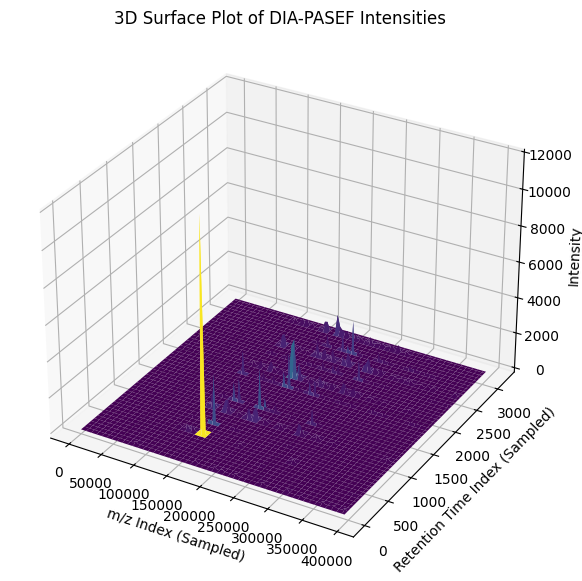

In [10]:
def plot_3d_surface(intensities, x_indices, y_indices):
    """
    Plots a 3D surface plot of DIA-PASEF intensities.

    Parameters:
    - intensities: numpy.ndarray, the intensity values.
    - x_indices: numpy.ndarray, sampled indices for the m/z dimension.
    - y_indices: numpy.ndarray, sampled indices for the retention time dimension.
    """
    # Create meshgrid for plotting
    X, Y = np.meshgrid(x_indices, y_indices)
    

    # Extract the downsampled intensity values
    intensities_small = intensities[np.ix_(y_indices, x_indices)]

    # Create 3D plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, intensities_small, cmap='viridis')

    ax.set_xlabel("m/z Index (Sampled)")
    ax.set_ylabel("Retention Time Index (Sampled)")
    ax.set_zlabel("Intensity")
    ax.set_title("3D Surface Plot of DIA-PASEF Intensities")

    plt.show()
    
    
x_indices = np.linspace(0, intensities.shape[1] - 1, num=100, dtype=int)  # m/z index (sampled)
y_indices = np.linspace(0, intensities.shape[0] - 1, num=100, dtype=int)  # rt index (sampled)
np.meshgrid(x_indices, y_indices)[0].shape
plot_3d_surface(intensities, x_indices, y_indices)

In [11]:
selected_precursor = data[:,:,0, 400.0: 425.0]
selected_precursor

,raw_indices,frame_indices,scan_indices,precursor_indices,push_indices,tof_indices,rt_values,rt_values_min,mobility_values,quad_low_mz_values,quad_high_mz_values,mz_values,intensity_values,corrected_intensity_values
0,3725,1,146,0,1074,127662,0.504660,0.008411,1.474541,-1.0,-1.0,404.242763,147,147
1,11663,1,206,0,1134,132644,0.504660,0.008411,1.407173,-1.0,-1.0,420.256525,80,80
2,13062,1,213,0,1141,130823,0.504660,0.008411,1.399315,-1.0,-1.0,414.367173,139,139
3,15065,1,222,0,1150,131141,0.504660,0.008411,1.389213,-1.0,-1.0,415.392632,10,10
4,17837,1,233,0,1161,131668,0.504660,0.008411,1.376867,-1.0,-1.0,417.094846,55,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2539456,126975343,3176,33,0,2947361,126996,337.172372,5.619540,1.601499,-1.0,-1.0,402.125593,33,33
2539457,126975344,3176,33,0,2947361,127026,337.172372,5.619540,1.601499,-1.0,-1.0,402.220841,138,138
2539458,126975345,3176,33,0,2947361,128881,337.172372,5.619540,1.601499,-1.0,-1.0,408.132281,122,122
2539459,126975346,3176,33,0,2947361,129883,337.172372,5.619540,1.601499,-1.0,-1.0,411.343353,140,140


In [12]:

import numpy as np
import pandas as pd


# finding the similar raws with the selected thresholds 
def group_similar_rows(df, rt_tolerance, mobility_tolerance, mz_tolerance):
    min_values = df.min()
    max_values = df.max()
    
    rt_min_value = min_values['rt_values']
    rt_max_value = max_values['rt_values']
    
    mobility_min_value = min_values['mobility_values']
    mobility_max_value = max_values['mobility_values']
    
    mz_min_values = min_values['mz_values']
    mz_max_values = max_values['mz_values']
    
    
    df = df.sort_values(by=["rt_values"]).reset_index(drop=True)
    rt_bins = np.arange(rt_min_value, rt_max_value + rt_tolerance, rt_tolerance)
    df["rt_group"] = pd.cut(df["rt_values"], rt_bins,  labels=rt_bins[:-1])
    
    
    df = df.sort_values(by=["mobility_values"]).reset_index(drop=True)
    mobility_bins = np.arange(mobility_min_value, mobility_max_value + mobility_tolerance, mobility_tolerance)
    df["mobility_group"] = pd.cut(df["mobility_values"], mobility_bins,  labels=mobility_bins[:-1])
    
    
    df = df.sort_values(by=["mz_values"]).reset_index(drop=True)
    mobility_bins = np.arange(mz_min_values, mz_max_values +mz_tolerance, mz_tolerance)
    df["mz_group"] = pd.cut(df["mz_values"], mobility_bins,  labels=mobility_bins[:-1])
    
    

    grouped_df = df.groupby(["rt_group", "mobility_group", "mz_group"], observed=True).agg({
        "raw_indices": "first",
        "rt_values": "mean",
        "mobility_values": "mean",
        "mz_values": "mean",
        "intensity_values": "sum"
    }).reset_index(drop=False)
    return grouped_df

In [13]:
grouped_window_1_precursors =  group_similar_rows(
    selected_precursor, 
    rt_tolerance= 60, 
    mobility_tolerance=0.06, 
    mz_tolerance= 0.1
    ).sort_values(by="intensity_values",ascending= False)


# this contains the peptide detector events in the selected quadropole window
# grouped_window_1_precursors.sort_values(by="mobility_values",ascending= False)
grouped_window_1_precursors.sort_values(by="mz_values")


,rt_group,mobility_group,mz_group,raw_indices,rt_values,mobility_values,mz_values,intensity_values
11780,240.50466,0.601114,400.001315,107761611,291.581747,0.659184,400.018731,342
18151,300.50466,1.381114,400.001315,125628372,333.568242,1.388091,400.020314,10
1856,0.50466,1.081114,400.001315,2389360,16.725823,1.123438,400.020314,10
4334,60.50466,1.081114,400.001315,4439341,61.579239,1.129040,400.020314,67
2205,0.50466,1.381114,400.001315,3554842,37.718847,1.427380,400.026647,95
...,...,...,...,...,...,...,...,...
4333,60.50466,1.021114,424.901315,12990978,101.341621,1.051749,424.975733,367
4719,60.50466,1.141114,424.901315,9452010,102.612299,1.157054,424.978997,31
11208,180.50466,1.201114,424.901315,63658481,207.595348,1.241689,424.982261,141
10796,180.50466,1.081114,424.901315,82361941,223.339735,1.121197,424.987156,228


In [14]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter, laplace

# Assuming df contains 'mz', 'rt', and 'intensity'
# Convert to a structured 3D grid
mz_values = np.unique(selected_precursor['mz_values'])
rt_values = np.unique(selected_precursor['rt_values'])
mz_grid, rt_grid = np.meshgrid(mz_values, rt_values, indexing='ij')

# Create an intensity grid
intensity_grid = np.zeros_like(mz_grid, dtype=float)
for _, row in selected_precursor.iterrows():
    mz_idx = np.where(mz_values == row['mz_values'])[0][0]
    rt_idx = np.where(rt_values == row['rt_values'])[0][0]
    intensity_grid[mz_idx, rt_idx] = row['intensity_values']

# Smooth the data to reduce noise
smoothed_intensity = gaussian_filter(intensity_grid, sigma=1)

# Compute second derivative (Laplacian for peak detection)
laplacian = laplace(smoothed_intensity)

# Detect zero crossings (sign change from - to +)
zero_crossings = np.where(np.diff(np.sign(laplacian), axis=0))

# Extract peak positions
peaks_mz = mz_values[zero_crossings[0]]
peaks_rt = rt_values[zero_crossings[1]]

# Store detected peaks
detected_peaks = pd.DataFrame({'mz': peaks_mz, 'rt': peaks_rt})

print(detected_peaks)


                mz          rt
0       400.001315    1.458463
1       400.001315    2.412704
2       400.001315    3.367612
3       400.001315    7.184911
4       400.001315    8.138084
...            ...         ...
944570  424.995316  333.568242
944571  424.995316  333.780183
944572  424.995316  335.371156
944573  424.995316  335.476938
944574  424.995316  335.901599

[944575 rows x 2 columns]


In [15]:
# plot_mz_intensity(detected_peaks)